<a href="https://colab.research.google.com/github/Manawariqbal/Data-science-code/blob/main/Resume_screening_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
#Load dataset
df=pd.read_csv('/content/UpdatedResumeDataSet.csv')

df.head()
#Exploring the catogores
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


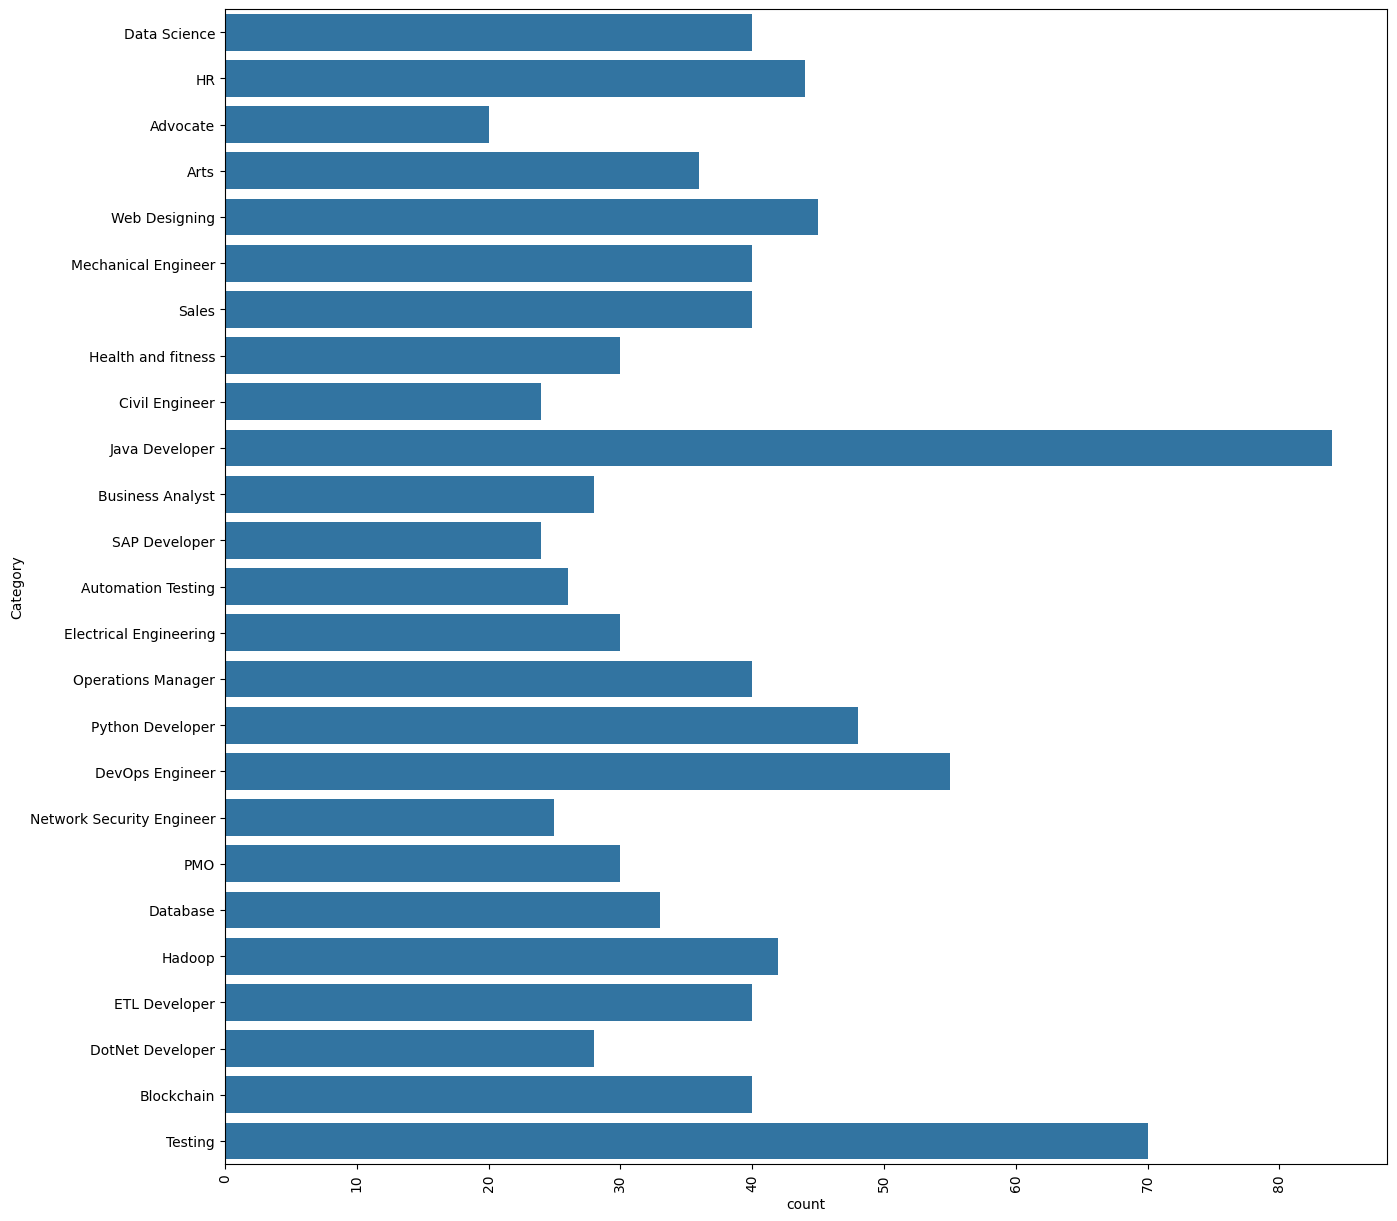

In [9]:
plt.figure(figsize=(15,15))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [10]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

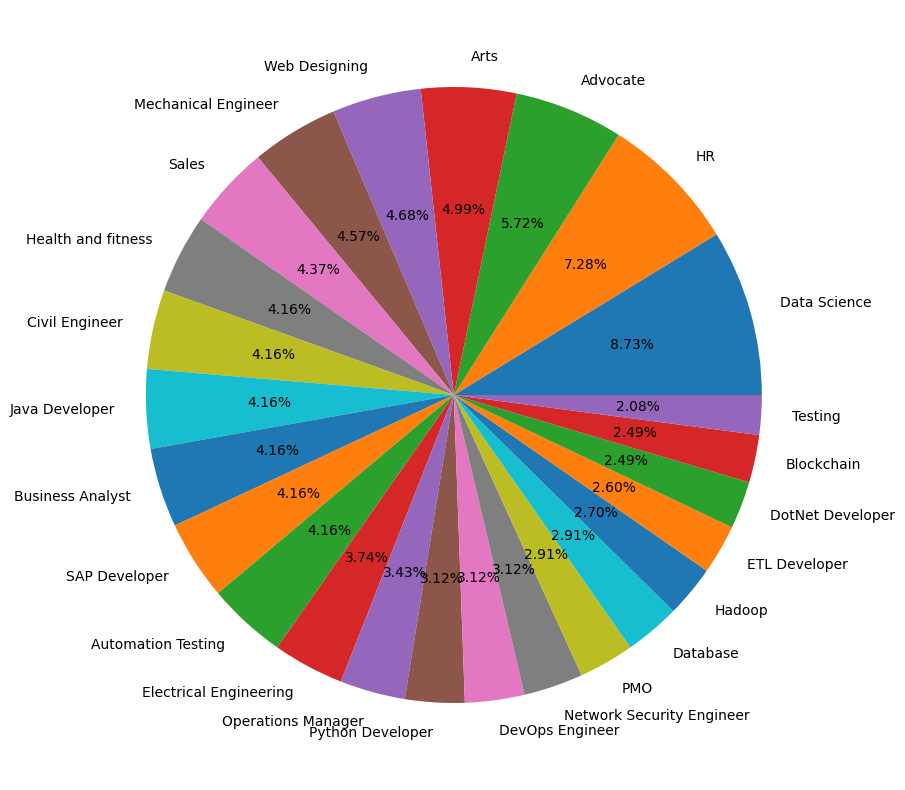

In [13]:
counts=df['Category'].value_counts()
labels=df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts,labels=labels,autopct='%1.2f%%')
plt.show()

In [15]:
#Exploring the resume
df.head()
df["Resume"][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [19]:
#Balance classess
#Check the original category distribution
print("Original Category Distribution")

print(df["Category"].value_counts())

#Get the largest category size
max_size=df["Category"].value_counts().max()
print(max_size)


#Perform oversampling


balanced_df=df.groupby('Category').apply(lambda x: x.sample(max_size,replace=True)).reset_index(drop=True)






Original Category Distribution
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64
84


In [21]:
#shuffle the dataset to avoid any order bias


df=balanced_df.sample(frac=1).reset_index(drop=True)


#Check the balanced category distribution
print("Balanced Category Distribution")
print(df["Category"].value_counts())

df.shape

Balanced Category Distribution
Category
Network Security Engineer    84
Automation Testing           84
Arts                         84
Hadoop                       84
Business Analyst             84
DevOps Engineer              84
PMO                          84
SAP Developer                84
Java Developer               84
Civil Engineer               84
Health and fitness           84
Electrical Engineering       84
Operations Manager           84
Blockchain                   84
Python Developer             84
Sales                        84
Data Science                 84
Advocate                     84
HR                           84
Testing                      84
Mechanical Engineer          84
Web Designing                84
Database                     84
DotNet Developer             84
ETL Developer                84
Name: count, dtype: int64


(2100, 2)

In [23]:
#Cleaning dataset

#URLS,Hasthag,mentions ,special letter,punctuations


import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText

In [24]:
cleanResume("my #### $ #  #noorsaeed webiste like is this http://heloword and access it @gmain.com")

'my webiste like is this and a ess it '

In [25]:
df["Resume"]=df["Resume"].apply(lambda x:cleanResume(x))


In [26]:
df['Resume'][0]

'Operating Systems Windows Linux Ubuntu Network Technologies Cisco Routing and Switching InterVLAN Routing Dynamic Protocols i e RIPv2 RIPng OSPF EIGRP Static Routing ACL VTP VLAN EhterChannel HSRP STP IPv6 Lan Troubleshooting Structured Network Cabling Cisco Firewall and Fortinet Firewall RHEL 6 networks Networking Devices Cisco Routers 1800s 1900s 2600s 2900s 3600s 3800s 7200s etc Cisco Switches Cisco Catalyst 2900s 3700s 4850s etc HP ProLiant Servers Dell Server Lenovo Servers etc Fortinet Firewall Modem etc Server Technologies AD RODC FTP Print Server SCCM WDS DHCP Group Policies DHCP Server DNS Server RIS Server User policies computer policies etc Backup Technologies Server 2016 backup tools Symantec Backup EXEC 12D etc Virtualisation VMWare ESXi VMware Workstation Oracle VirtualBox GNS3 Network Simulator etc Education Details MSC AISECT university in distance education B Com Jiwaji University Sr Network Engineer Sr Network Engineer Cloudatix Network Pvt Ltd Skill Details CISCO Ex

In [28]:
#Words  into Categorical values


from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df['Category'])
df["Category"]=le.transform(df["Category"])

In [30]:
df['Category'].unique()
df.head()

,Category,Resume
0,17,Operating Systems Windows Linux Ubuntu Network...
1,2,SKILLS Agile Methodology Scrum Kanban Extreme ...
2,1,Additional qualifications April 2000 Web Desig...
3,13,Technical Skill Set Programming Languages Apac...
4,4,IT Skills Area Exposure Modeling Tool Bizagi M...


In [34]:
#Vectroization using tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf=TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
required_text=tfidf.fit_transform(df['Resume'])


In [37]:
#Train test splitter
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(required_text,df['Category'],test_size=0.2,random_state=42)


In [38]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 75467 stored elements and shape (420, 7335)>

In [41]:
#Train the model and print classification reports

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Ensure that X_train and X_test are dense if they are sparse
X_train = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9929
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  

In [42]:
# 2. Train SVC
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")


SVC Results:
Accuracy: 1.0000
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0 

In [43]:
# 3. Train RandomForestClassifier
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[18  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 18  0  0  0  0  0

In [44]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

In [45]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume)

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])

    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]

In [47]:
myresume = """
ARJUN SHARMA
Java Full Stack Developer

Email: arjun.sharma.dev@gmail.com
Phone: +91-98765-43210
Location: Pune, Maharashtra, India
LinkedIn: linkedin.com/in/arjun-sharma-dev
GitHub: github.com/arjunsharma-dev

PROFESSIONAL SUMMARY

Java Full Stack Developer with 4+ years of experience designing, developing, and maintaining scalable enterprise applications using Java, Spring Boot, REST APIs, Microservices, React, and PostgreSQL. Strong experience in backend development, API integration, database optimization, containerization, and CI/CD. Experienced in developing cloud-ready applications and working in Agile environments.

TECHNICAL SKILLS

Programming Languages:
Java 8, Java 11, Java 17, SQL, JavaScript, TypeScript

Backend Technologies:
Spring Boot, Spring MVC, Spring Security, Spring Data JPA, Hibernate, JDBC, REST APIs, Microservices

Frontend Technologies:
React.js, HTML5, CSS3, JavaScript, Bootstrap

Databases:
PostgreSQL, MySQL, Oracle, MongoDB, Redis

Messaging:
Apache Kafka, RabbitMQ

Cloud & DevOps:
AWS EC2, AWS S3, AWS RDS, Docker, Kubernetes, Jenkins, GitHub Actions

Tools:
Git, GitHub, Maven, Gradle, IntelliJ IDEA, Postman, Swagger/OpenAPI, JUnit, Mockito

Architecture:
Microservices, Monolithic Architecture, RESTful Services, Event-Driven Architecture

Methodologies:
Agile, Scrum, CI/CD, Test-Driven Development

PROFESSIONAL EXPERIENCE

Senior Software Engineer
TechNova Solutions Pvt. Ltd., Pune, India
July 2024 – Present

• Developed and maintained scalable Java-based backend applications using Java 17 and Spring Boot.
• Designed and implemented RESTful APIs for customer management, authentication, payments, and order processing.
• Developed microservices using Spring Boot and Spring Cloud.
• Implemented authentication and authorization using Spring Security and JWT.
• Used Spring Data JPA and Hibernate for database operations.
• Optimized PostgreSQL queries and database indexes, reducing average API response time by approximately 30%.
• Integrated Apache Kafka for asynchronous communication between microservices.
• Implemented Redis caching for frequently accessed customer and product information.
• Created unit and integration tests using JUnit 5 and Mockito.
• Containerized applications using Docker and deployed services to Kubernetes.
• Created CI/CD pipelines using Jenkins and GitHub Actions.
• Worked closely with frontend developers to integrate React applications with backend REST APIs.
• Participated in code reviews, sprint planning, backlog refinement, and daily Scrum meetings.
• Investigated production issues and performed root cause analysis.
• Created API documentation using Swagger/OpenAPI.

Key Project: E-Commerce Order Management Platform

Technologies: Java 17, Spring Boot, Spring Security, Kafka, PostgreSQL, Redis, Docker, Kubernetes, AWS

• Developed order, payment, inventory, and customer microservices.
• Implemented Kafka-based event processing for order status updates.
• Designed REST APIs supporting order creation, cancellation, tracking, and payment processing.
• Implemented Redis caching to improve performance of product and customer lookup operations.
• Used PostgreSQL for transactional data and optimized complex SQL queries.
• Deployed microservices using Docker and Kubernetes on AWS.
• Implemented centralized logging and monitoring for production services.


Software Engineer
InnoSoft Technologies Ltd., Hyderabad, India
August 2022 – June 2024

• Developed enterprise applications using Java 11, Spring Boot, Spring MVC, and Hibernate.
• Built REST APIs for internal business applications.
• Implemented CRUD operations using Spring Data JPA.
• Developed authentication and authorization modules using Spring Security.
• Worked with MySQL and Oracle databases.
• Developed reusable service and repository layers following clean architecture principles.
• Fixed production bugs and improved application stability.
• Wrote unit tests using JUnit and Mockito.
• Used Maven for dependency management and build automation.
• Participated in Agile development and sprint-based delivery.
• Used Git and GitHub for version control.
• Collaborated with QA engineers to troubleshoot integration and functional issues.
• Performed API testing using Postman.
• Maintained technical documentation for APIs and application modules.

Key Project: Banking Customer Management System

Technologies: Java 11, Spring Boot, Hibernate, MySQL, React.js, Docker

• Developed customer onboarding and account management modules.
• Implemented REST APIs for customer registration, account details, and transaction history.
• Added validation and exception handling using Spring Boot.
• Implemented role-based access control using Spring Security.
• Integrated React.js frontend with Spring Boot backend.
• Improved database performance by optimizing SQL queries and Hibernate mappings.


PROJECTS

Employee Management System

Technologies: Java, Spring Boot, Spring Data JPA, PostgreSQL, React.js

• Built a full-stack employee management application.
• Implemented employee CRUD operations and role-based access control.
• Developed REST APIs using Spring Boot.
• Integrated PostgreSQL using Spring Data JPA.
• Created a responsive frontend using React.js.
• Added JWT-based authentication.
• Implemented global exception handling and request validation.


Real-Time Notification Service

Technologies: Java 17, Spring Boot, Apache Kafka, Redis, Docker

• Developed a notification microservice capable of processing asynchronous events.
• Used Apache Kafka for event streaming and message processing.
• Implemented Redis for temporary notification state management.
• Added retry mechanisms for failed message processing.
• Containerized the service using Docker.


EDUCATION

Bachelor of Technology (B.Tech) – Computer Science and Engineering
Maulana Abul Kalam Azad University of Technology
2018 – 2022
CGPA: 8.7/10

CERTIFICATIONS

• AWS Certified Cloud Practitioner
• Oracle Certified Professional: Java SE Developer
• Spring Boot and Microservices Certification

ACHIEVEMENTS

• Received "Spot Award" for successfully delivering a critical backend module before the release deadline.
• Improved API response time by approximately 30% through database query optimization and Redis caching.
• Contributed to migration of legacy monolithic services to Spring Boot microservices.
• Mentored junior developers on Java, Spring Boot, REST APIs, and Git.

SOFT SKILLS

• Problem Solving
• Communication
• Team Collaboration
• Leadership
• Analytical Thinking
• Agile/Scrum
• Mentoring

LANGUAGES

English – Professional
Hindi – Native
Bengali – Native

DECLARATION

I hereby declare that the information provided above is true and correct to the best of my knowledge.

Arjun Sharma
Pune, Maharashtra
"""

pred(myresume)

'Java Developer'

In [48]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Health and Fitness-focused resume
pred(myresume)

'Health and fitness'